# 09 — TKG & T-Logic Visualization

Four figures for UseCase 4 (EPC compliance, TR Meram dataset):

| Figure | Content |
|--------|---------|
| **Fig 1** | TKG schema — entity types, relation types, which edges carry bitemporal timestamps |
| **Fig 2** | Instance subgraph — 3 real workers, hot_work permit, certifications, PERMIT_DENIED |
| **Fig 3** | Bitemporal semantics — valid-time x transaction-time + worker compliance timeline |
| **Fig 4** | T-Logic rules — R1 MissingCert and R2 PostRuleChange as graph-path diagrams |

PNGs saved to `experiments/UseCase4/results/`.

## 0. Setup & Data

In [1]:
"""Test TKG + bitemporal + T-Logic visualizations."""
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from collections import defaultdict
from pathlib import Path
from datetime import datetime

DATA_DIR  = Path("../../data/UseCase4")
OUT_DIR   = Path("../../experiments/UseCase4/results")

d   = json.load(open(DATA_DIR / "epc_dataset_real.json", encoding="utf-8"))
ev  = json.load(open(DATA_DIR / "epc_events.json",       encoding="utf-8"))

workers      = {w["id"]: w for w in d["workers"]}
steps        = {s["id"]: s for s in d["steps"]}
work_permits = {wp["id"]: wp for wp in d["work_permits"]}
assigned     = ev["assigned_to"]
denied       = ev["permit_denied"]
update_ev    = d["update_events"][0]

# ── cert requirements (from nb07) ────────────────────────────────────────────
CERT_REQS_PRE = {
    "hot_work":       {"Hot_Work_Safety", "Fire_Watch", "Welding_Certification"},
    "excavation":     {"Excavation_Safety", "Confined_Space_Entry"},
    "lifting":        {"Rigging_Certification", "Crane_Operation"},
    "electrical":     {"Electrical_Safety", "LOTO_Certification"},
    "confined_space": {"Confined_Space_Entry", "Gas_Detection"},
    "radiography":    {"Radiation_Safety", "NDT_Level_II"},
    "work_at_height": {"Working_at_Height", "Fall_Protection"},
}
CERT_REQS_POST = {**CERT_REQS_PRE,
                  "hot_work": {"Hot_Work_Safety", "Fire_Watch",
                               "Welding_Certification", "Advanced_Fire_Watch"}}

RULE_CHANGE = datetime.fromisoformat("2024-06-29T00:00:00+00:00")

## Fig 1 — TKG Schema (ontology level)

**Entity types** (nodes) and **relation types** (edges) in the EPC TKG. Solid edges: static (no time attributes). Dashed/dotted: **bitemporally versioned** — carry `valid_from` / `valid_to` (when the fact holds in the real world) and `tx_time` (when recorded in the DB).

This two-axis time model (Snodgrass 1999) lets you ask: *which certifications were required on date X, as known at date Y?*

Saved viz_tkg_schema.png


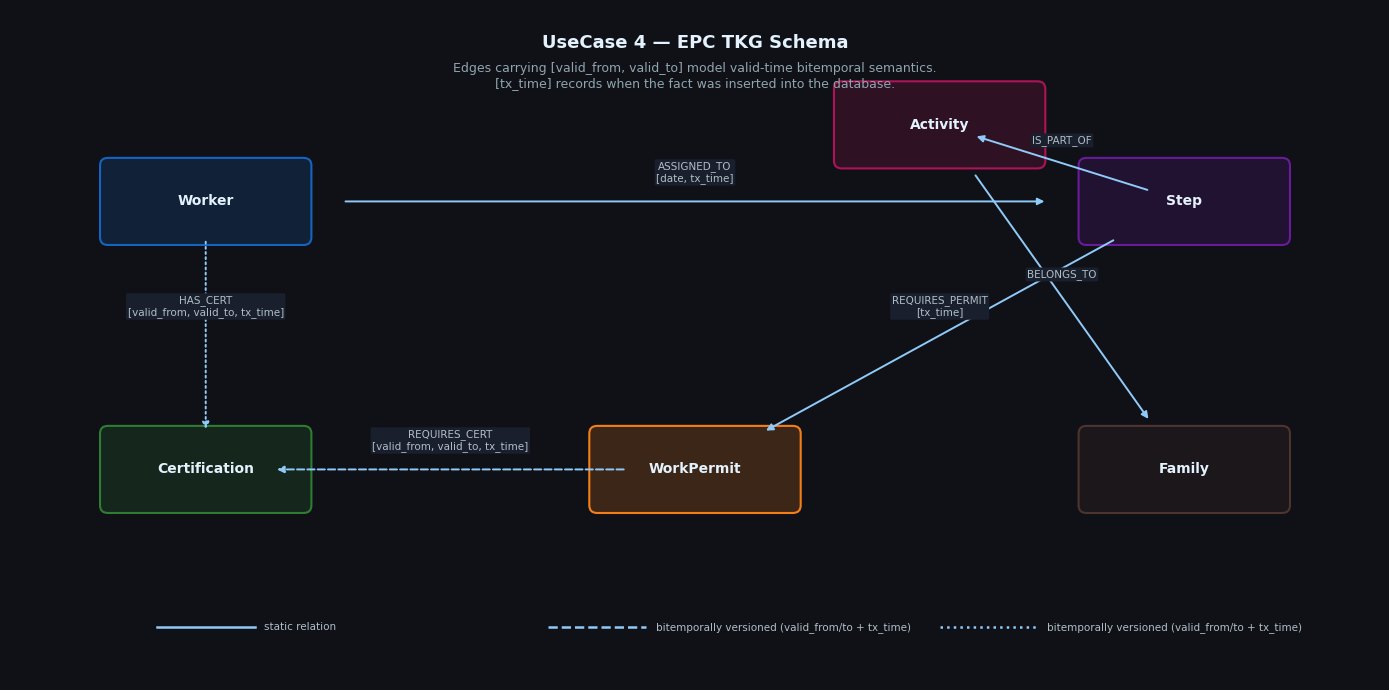

In [2]:
fig1, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7)
ax.axis("off")
fig1.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")

NODE_COLORS = {
    "Worker":     "#1565C0",
    "Certification": "#2E7D32",
    "WorkPermit": "#F57F17",
    "Step":       "#6A1B9A",
    "Activity":   "#AD1457",
    "Family":     "#4E342E",
}
EDGE_COLOR = "#90CAF9"
TEXT_COLOR = "#E3F2FD"

# Node positions (x, y)
nodes = {
    "Worker":        (2,   5.0),
    "Certification": (2,   2.2),
    "WorkPermit":    (7,   2.2),
    "Step":          (12,  5.0),
    "Activity":      (9.5, 5.8),
    "Family":        (12,  2.2),
}

def draw_node(ax, label, pos, color, w=2.0, h=0.75):
    x, y = pos
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.08", linewidth=1.5,
                         edgecolor=color, facecolor=color + "33")
    ax.add_patch(box)
    ax.text(x, y, label, ha="center", va="center",
            fontsize=10, fontweight="bold", color=TEXT_COLOR)

for label, pos in nodes.items():
    draw_node(ax, label, pos, NODE_COLORS[label])

# Edges: (from, to, label, valid_time_attrs, style)
edges = [
    ("Worker",      "Certification", "HAS_CERT\n[valid_from, valid_to, tx_time]",   "dotted"),
    ("WorkPermit",  "Certification", "REQUIRES_CERT\n[valid_from, valid_to, tx_time]", "dashed"),
    ("Worker",      "Step",          "ASSIGNED_TO\n[date, tx_time]",                "solid"),
    ("Step",        "WorkPermit",    "REQUIRES_PERMIT\n[tx_time]",                  "solid"),
    ("Step",        "Activity",      "IS_PART_OF",                                  "solid"),
    ("Activity",    "Family",        "BELONGS_TO",                                  "solid"),
]

def arrow(ax, p1, p2, label, style):
    x1, y1 = p1; x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    ls = {"solid": "-", "dashed": "--", "dotted": ":"}[style]
    ax.annotate("", xy=(x2 - dx*0.14, y2 - dy*0.14),
                xytext=(x1 + dx*0.14, y1 + dy*0.14),
                arrowprops=dict(arrowstyle="-|>", color=EDGE_COLOR,
                                lw=1.4, linestyle=ls,
                                connectionstyle="arc3,rad=0.0"))
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx, my + 0.18, label, ha="center", va="bottom",
            fontsize=7.5, color="#B0BEC5",
            bbox=dict(boxstyle="round,pad=0.15", fc="#1a1f2e", ec="none"))

for src, dst, lbl, sty in edges:
    arrow(ax, nodes[src], nodes[dst], lbl, sty)

# Legend: edge style meaning
leg_y = 0.55
for x_pos, (sty, meaning) in zip([2, 6, 10], [
        ("solid",  "static relation"),
        ("dashed", "bitemporally versioned (valid_from/to + tx_time)"),
        ("dotted", "bitemporally versioned (valid_from/to + tx_time)")]):
    ls = {"solid": "-", "dashed": "--", "dotted": ":"}[sty]
    ax.plot([x_pos - 0.5, x_pos + 0.5], [leg_y, leg_y],
            linestyle=ls, color=EDGE_COLOR, lw=1.8)
    ax.text(x_pos + 0.6, leg_y, meaning, va="center",
            fontsize=7.5, color="#B0BEC5")

ax.text(7, 6.6, "UseCase 4 — EPC TKG Schema", ha="center",
        fontsize=13, fontweight="bold", color=TEXT_COLOR)
ax.text(7, 6.2,
        "Edges carrying [valid_from, valid_to] model valid-time bitemporal semantics.\n"
        "[tx_time] records when the fact was inserted into the database.",
        ha="center", fontsize=9, color="#90A4AE")

fig1.tight_layout()
fig1.savefig(OUT_DIR / "viz_tkg_schema.png", dpi=160, bbox_inches="tight",
             facecolor=fig1.get_facecolor())
print("Saved viz_tkg_schema.png")

## Fig 2 — Instance Subgraph: 3 workers × hot_work permit

A real subgraph extracted from the dataset: 3 workers (W-001, W-007, W-023), their certifications, the hot_work WorkPermit, the rule-change event, and a PERMIT_DENIED outcome.

- Yellow dashed edges: `REQUIRES_CERT` **pre**-rule (valid_to = 2024-06-28)
- Orange edge: `REQUIRES_CERT` **post**-rule (Advanced Fire Watch, valid_from = 2024-06-29)
- Red node: PERMIT_DENIED — the outcome T-Logic R2 predicts for W-001 after the rule change

Saved viz_tkg_instance.png


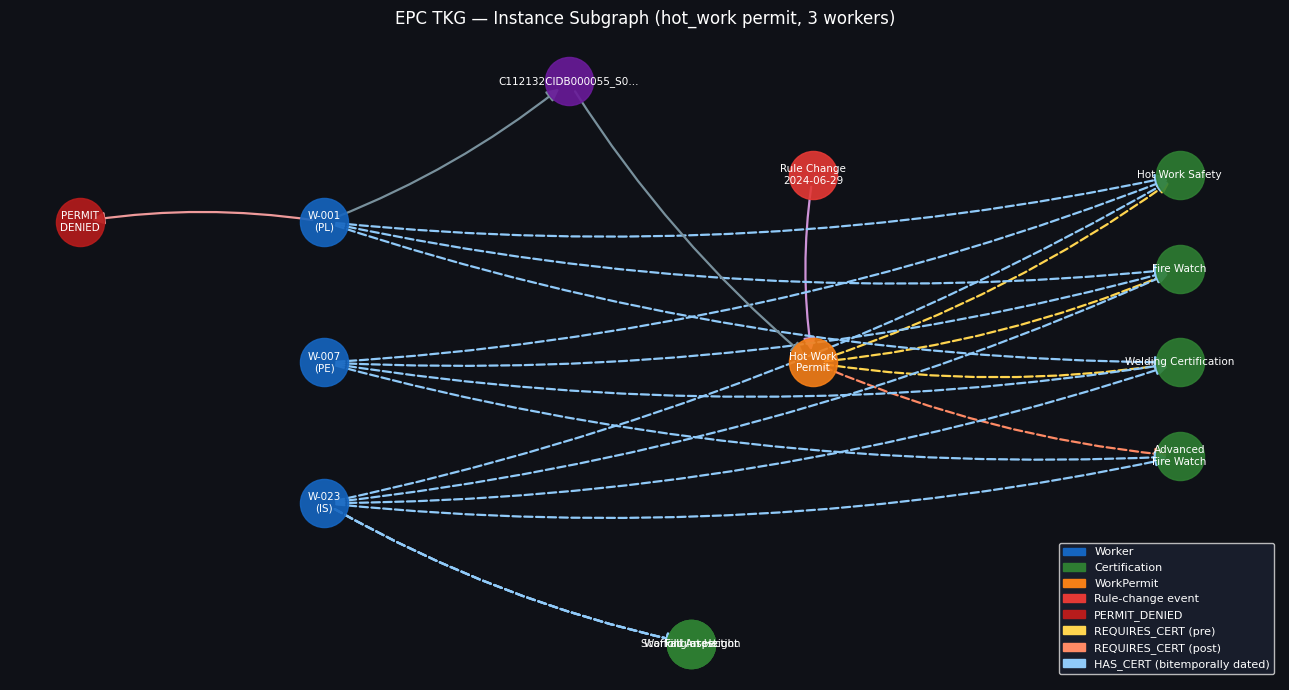

In [3]:
import networkx as nx

focus_workers = ["W-001", "W-007", "W-023"]   # 2 lost compliance, 1 retained
PERMIT = "hot_work"

G = nx.DiGraph()

# Nodes
G.add_node("hot_work",   type="permit",  label="Hot Work\nPermit")
G.add_node("RC",         type="event",   label="Rule Change\n2024-06-29")
for wid in focus_workers:
    w = workers[wid]
    G.add_node(wid, type="worker", label=f"{wid}\n({w['discipline']})")
    for c in w["certifications"]:
        cid = c["cert"].replace(" ", "_")
        G.add_node(cid, type="cert", label=c["cert"].replace("_", " "),
                   valid_from=c["valid_from"][:10], valid_to=c["valid_to"][:10])
        G.add_edge(wid, cid, rel="HAS_CERT",
                   valid_from=c["valid_from"][:10], valid_to=c["valid_to"][:10])

# REQUIRES_CERT edges (pre and post)
for cert in CERT_REQS_PRE[PERMIT]:
    cid = cert.replace(" ", "_")
    G.add_node(cid, type="cert", label=cert.replace("_", " "))
    G.add_edge("hot_work", cid, rel="REQUIRES_CERT_PRE", valid_from="2024-01-01", valid_to="2024-06-28")
new_cert = "Advanced_Fire_Watch"
G.add_node(new_cert, type="cert", label="Advanced\nFire Watch")
G.add_edge("hot_work", new_cert, rel="REQUIRES_CERT_POST", valid_from="2024-06-29", valid_to="∞")
G.add_edge("RC", "hot_work", rel="UPDATE")

# Sample denied event for W-001
denied_w001 = [x for x in denied if x["worker_id"] == "W-001"][:1]
if denied_w001:
    e = denied_w001[0]
    sid = e["step_id"][:20] + "…"
    G.add_node(sid, type="step", label=sid)
    G.add_edge("W-001", sid, rel="ASSIGNED_TO", date=e["date"][:10])
    G.add_edge(sid, "hot_work", rel="REQUIRES_PERMIT")
    G.add_node("DENIED_W001", type="violation", label="PERMIT\nDENIED")
    G.add_edge("W-001", "DENIED_W001", rel="VIOLATION")

# Layout
pos = {
    "W-001": (0, 4),  "W-007": (0, 2.5), "W-023": (0, 1),
    "hot_work": (4, 2.5),  "RC": (4, 4.5),
    "Hot_Work_Safety":      (7, 4.5),
    "Fire_Watch":           (7, 3.5),
    "Welding_Certification":(7, 2.5),
    "Advanced_Fire_Watch":  (7, 1.5),
    "DENIED_W001":          (-2, 4),
}
# Auto-position remaining cert nodes for workers
all_certs = [n for n in G.nodes if G.nodes[n].get("type") == "cert"]
unpositioned = [c for c in all_certs if c not in pos]
# Add only worker-connected certs not already positioned
worker_certs = set()
for wid in focus_workers:
    for _, cid, data in G.out_edges(wid, data=True):
        worker_certs.add(cid)
for n in G.nodes:
    if n not in pos:
        if G.nodes[n].get("type") == "step":
            pos[n] = (2, 5.5)
        else:
            pos[n] = (3, -0.5)  # push off screen

fig2, ax = plt.subplots(figsize=(13, 7))
ax.set_facecolor("#0f1117"); fig2.patch.set_facecolor("#0f1117")
ax.axis("off")

NCOLORS = {"worker": "#1565C0", "cert": "#2E7D32", "permit": "#F57F17",
           "event": "#E53935", "step": "#6A1B9A", "violation": "#B71C1C"}

for ntype, color in NCOLORS.items():
    nodelist = [n for n in G.nodes if G.nodes[n].get("type") == ntype and n in pos]
    nx.draw_networkx_nodes(G, pos, nodelist=nodelist, node_color=color,
                           node_size=1200, ax=ax, alpha=0.9)

# Edge styling
for u, v, data in G.edges(data=True):
    if u not in pos or v not in pos: continue
    rel = data.get("rel", "")
    color = ("#90CAF9" if rel == "HAS_CERT" else
             "#FFD54F" if rel == "REQUIRES_CERT_PRE" else
             "#FF8A65" if rel == "REQUIRES_CERT_POST" else
             "#EF9A9A" if rel == "VIOLATION" else
             "#CE93D8" if rel == "UPDATE" else "#78909C")
    style = "dashed" if "CERT" in rel else "solid"
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color=color,
                           style=style, ax=ax, arrows=True, arrowsize=18,
                           width=1.6, connectionstyle="arc3,rad=0.08")

labels = {n: G.nodes[n].get("label", n) for n in G.nodes if n in pos}
nx.draw_networkx_labels(G, pos, labels=labels, font_color="white",
                        font_size=7.5, ax=ax)

# Legend
legend_elems = [
    mpatches.Patch(color="#1565C0", label="Worker"),
    mpatches.Patch(color="#2E7D32", label="Certification"),
    mpatches.Patch(color="#F57F17", label="WorkPermit"),
    mpatches.Patch(color="#E53935", label="Rule-change event"),
    mpatches.Patch(color="#B71C1C", label="PERMIT_DENIED"),
    mpatches.Patch(color="#FFD54F", label="REQUIRES_CERT (pre)"),
    mpatches.Patch(color="#FF8A65", label="REQUIRES_CERT (post)"),
    mpatches.Patch(color="#90CAF9", label="HAS_CERT (bitemporally dated)"),
]
ax.legend(handles=legend_elems, loc="lower right", fontsize=8,
          facecolor="#1a1f2e", labelcolor="white", framealpha=0.9)
ax.set_title("EPC TKG — Instance Subgraph (hot_work permit, 3 workers)",
             color="white", fontsize=12, pad=10)
fig2.tight_layout()
fig2.savefig(OUT_DIR / "viz_tkg_instance.png", dpi=160, bbox_inches="tight",
             facecolor=fig2.get_facecolor())
print("Saved viz_tkg_instance.png")

## Fig 3 — Bitemporal Semantics

**Left:** 2D bitemporal rectangle diagram for the `REQUIRES_CERT (hot_work)` relation.
- X-axis = **valid time** (when the rule holds in the real world)
- Y-axis = **transaction time** (when the fact was written to the database)

Two versions coexist in the DB: the pre-rule version (valid 2024-01 to 2024-06-29) and the post-rule version (+Advanced Fire Watch, valid from 2024-06-29), both recorded at dataset generation time.

**Right:** which workers are qualified vs non-compliant before and after the rule change. W-001 and W-002 lost compliance because they lacked Advanced Fire Watch.

Saved viz_bitemporal.png


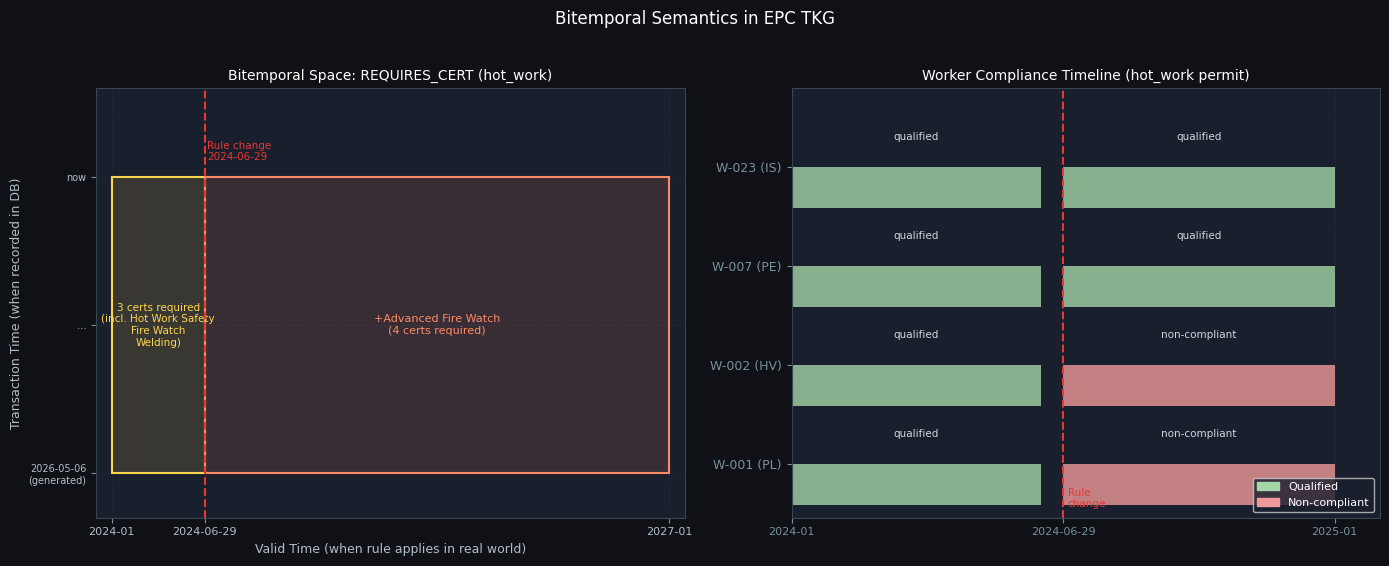

In [4]:
fig3, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig3.patch.set_facecolor("#0f1117")
for ax in axes:
    ax.set_facecolor("#1a1f2e")

# ── Left: 2D bitemporal space ─────────────────────────────────────────────────
ax = axes[0]
# Valid time axis (x): what period does the rule cover in the real world
# Transaction time axis (y): when was this fact recorded in the DB
VT = {"pre":  ("2024-01-01", "2024-06-29"),
      "post": ("2024-06-29", "2027-01-01")}
TT_RECORDED = "2026-05-06"   # both facts recorded at dataset generation time

# We plot the two "bitemporal rectangles" in the VT × TT plane
# Pre-rule: valid 2024-01 → 2024-06-29, recorded 2026-05-06 → now
# Post-rule: valid 2024-06-29 → ∞, recorded 2026-05-06 → now
vt_dates  = ["2024-01", "2024-06", "2024-07", "2025-01", "2026-01", "2027-01"]
vt_ticks  = [0, 5, 6, 12, 24, 36]
tt_dates  = ["2026-05-06", "2026-05-13"]
tt_ticks  = [0, 1]

ax.set_xlabel("Valid Time (when rule applies in real world)", color="#B0BEC5", fontsize=9)
ax.set_ylabel("Transaction Time (when recorded in DB)", color="#B0BEC5", fontsize=9)
ax.tick_params(colors="#78909C")
ax.spines[:].set_color("#37474F")

# Pre-rule rectangle  VT: 0→6  TT: 0→1
pre = plt.Rectangle((0, 0), 6, 1, linewidth=1.5,
                     edgecolor="#FFD54F", facecolor="#FFD54F22", zorder=2)
ax.add_patch(pre)
ax.text(3, 0.5, "3 certs required\n(incl. Hot Work Safety\nFire Watch\nWelding)", ha="center",
        va="center", fontsize=7.5, color="#FFD54F")

# Post-rule rectangle  VT: 6→36  TT: 0→1
post = plt.Rectangle((6, 0), 30, 1, linewidth=1.5,
                      edgecolor="#FF8A65", facecolor="#FF8A6522", zorder=2)
ax.add_patch(post)
ax.text(21, 0.5, "+Advanced Fire Watch\n(4 certs required)", ha="center",
        va="center", fontsize=8, color="#FF8A65")

# Rule change vertical line
ax.axvline(6, color="#E53935", lw=1.5, ls="--", zorder=3)
ax.text(6.15, 1.05, "Rule change\n2024-06-29", color="#E53935", fontsize=7.5, va="bottom")

ax.set_xlim(-1, 37); ax.set_ylim(-0.15, 1.3)
ax.set_xticks([0, 6, 36]); ax.set_xticklabels(["2024-01", "2024-06-29", "2027-01"],
                                                color="#B0BEC5", fontsize=8)
ax.set_yticks([0, 0.5, 1]); ax.set_yticklabels(["2026-05-06\n(generated)", "…", "now"],
                                                  color="#B0BEC5", fontsize=7)
ax.set_title("Bitemporal Space: REQUIRES_CERT (hot_work)", color="white", fontsize=10)
ax.grid(True, ls=":", alpha=0.2, color="#546E7A")

# ── Right: worker cert timeline vs rule-change ────────────────────────────────
ax = axes[1]
# Show 4 workers: 3 that retained + 1 that lost (W-001)
sel_workers = ["W-001", "W-002", "W-007", "W-023"]
REQ_PRE  = {"Hot_Work_Safety", "Fire_Watch", "Welding_Certification"}
REQ_POST = REQ_PRE | {"Advanced_Fire_Watch"}

y_ticks, y_labels = [], []
colors_w = {"W-001": "#EF9A9A", "W-002": "#EF9A9A", "W-007": "#A5D6A7", "W-023": "#A5D6A7"}

for yi, wid in enumerate(sel_workers):
    w = workers[wid]
    certs_held = {c["cert"].replace(" ", "_") for c in w["certifications"]}
    pre_ok  = REQ_PRE  <= certs_held
    post_ok = REQ_POST <= certs_held
    y = yi * 1.2

    # Pre-rule period bar
    color_pre  = "#A5D6A7" if pre_ok  else "#EF9A9A"
    color_post = "#A5D6A7" if post_ok else "#EF9A9A"
    ax.barh(y, 5.5, left=0, height=0.5, color=color_pre,  alpha=0.8)
    ax.barh(y, 6,   left=6, height=0.5, color=color_post, alpha=0.8)
    status_pre  = "qualified" if pre_ok  else "missing certs"
    status_post = "qualified" if post_ok else "non-compliant"
    ax.text(2.75, y + 0.55, status_pre,  ha="center", va="bottom", fontsize=7.5, color="#CFD8DC")
    ax.text(9,    y + 0.55, status_post, ha="center", va="bottom", fontsize=7.5, color="#CFD8DC")

    y_ticks.append(y + 0.25)
    y_labels.append(f"{wid} ({w['discipline']})")

ax.axvline(6, color="#E53935", lw=1.5, ls="--")
ax.set_xlim(0, 13); ax.set_ylim(-0.4, len(sel_workers) * 1.2)
ax.set_xticks([0, 6, 12]); ax.set_xticklabels(["2024-01", "2024-06-29", "2025-01"],
                                                color="#B0BEC5", fontsize=8)
ax.set_yticks(y_ticks); ax.set_yticklabels(y_labels, color="#B0BEC5", fontsize=9)
ax.text(6.1, -0.3, "Rule\nchange", color="#E53935", fontsize=7.5, va="bottom")
ax.set_title("Worker Compliance Timeline (hot_work permit)", color="white", fontsize=10)
ax.spines[:].set_color("#37474F"); ax.tick_params(colors="#78909C")
ax.set_facecolor("#1a1f2e")
ax.grid(True, ls=":", alpha=0.2, color="#546E7A", axis="x")

legend_elems = [mpatches.Patch(color="#A5D6A7", label="Qualified"),
                mpatches.Patch(color="#EF9A9A", label="Non-compliant")]
ax.legend(handles=legend_elems, loc="lower right", fontsize=8,
          facecolor="#1a1f2e", labelcolor="white")

fig3.suptitle("Bitemporal Semantics in EPC TKG", color="white", fontsize=12, y=1.02)
fig3.tight_layout()
fig3.savefig(OUT_DIR / "viz_bitemporal.png", dpi=160, bbox_inches="tight",
             facecolor=fig3.get_facecolor())
print("Saved viz_bitemporal.png")

## Fig 4 — T-Logic Rule Diagrams (R1 + R2)

**R1 — MissingCert rule:**
Worker W `ASSIGNED_TO` Step S at time t, S `REQUIRES_PERMIT` P, P `REQUIRES_CERT` C (valid at t), but W does NOT `HAS_CERT` C (valid at t) → PERMIT_DENIED.

**R2 — PostRuleChange rule:**
Same chain, but the cert (Advanced Fire Watch) was introduced by the rule-change event RC = 2024-06-29; fires only for assignments **after** RC.

Both rules are temporal path queries on the TKG: the T-Logic formalism evaluates body predicates as **temporal graph walks** with time-interval constraints, then fires the head predicate.

Saved viz_tlogic_rules.png

All done.


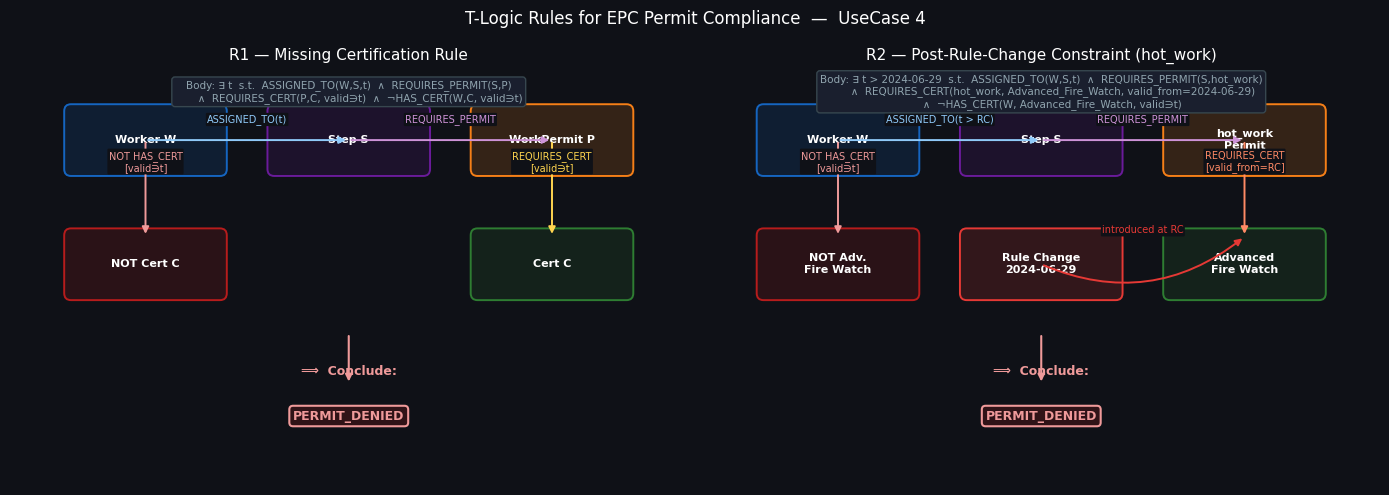

In [5]:
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))
fig4.patch.set_facecolor("#0f1117")

def tlogic_panel(ax, title, nodes_cfg, edges_cfg, conclusion):
    ax.set_xlim(0, 10); ax.set_ylim(0, 6)
    ax.axis("off"); ax.set_facecolor("#0f1117")

    # Nodes
    for (x, y, lbl, color) in nodes_cfg:
        box = FancyBboxPatch((x - 1.1, y - 0.42), 2.2, 0.84,
                             boxstyle="round,pad=0.1", lw=1.4,
                             edgecolor=color, facecolor=color + "2a")
        ax.add_patch(box)
        ax.text(x, y, lbl, ha="center", va="center",
                fontsize=8, fontweight="bold", color="white")

    # Edges
    for (x1, y1, x2, y2, lbl, color, rad) in edges_cfg:
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=1.4,
                                   connectionstyle=f"arc3,rad={rad}"))
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.22, lbl, ha="center", va="bottom",
                fontsize=7, color=color,
                bbox=dict(boxstyle="round,pad=0.12", fc="#0f1117", ec="none"))

    # Conclusion box
    cx, cy = conclusion
    ax.text(cx, cy, "PERMIT_DENIED", ha="center", va="center",
            fontsize=9, fontweight="bold", color="#EF9A9A",
            bbox=dict(boxstyle="round,pad=0.3", fc="#B71C1C33", ec="#EF9A9A", lw=1.5))
    ax.annotate("", xy=(cx, cy + 0.46), xytext=(5, 2.2),
                arrowprops=dict(arrowstyle="-|>", color="#EF9A9A", lw=1.5,
                                connectionstyle="arc3,rad=0.0"))
    ax.text(5, 1.6, "⟹  Conclude:", ha="center", fontsize=9,
            color="#EF9A9A", fontweight="bold")

    ax.set_title(title, color="white", fontsize=11, pad=8)

# ── R1: MissingCert rule ───────────────────────────────────────────────────────
ax = axes[0]
nodes_r1 = [
    (2, 5,   "Worker W",    "#1565C0"),
    (5, 5,   "Step S",      "#6A1B9A"),
    (8, 5,   "WorkPermit P","#F57F17"),
    (8, 3.2, "Cert C",      "#2E7D32"),
    (2, 3.2, "NOT Cert C",   "#B71C1C"),
]
edges_r1 = [
    (2, 5, 5, 5,   "ASSIGNED_TO(t)",         "#90CAF9", 0.0),
    (5, 5, 8, 5,   "REQUIRES_PERMIT",         "#CE93D8", 0.0),
    (8, 5, 8, 3.6, "REQUIRES_CERT\n[valid∋t]","#FFD54F", 0.0),
    (2, 5, 2, 3.6, "NOT HAS_CERT\n[valid∋t]", "#EF9A9A", 0.0),
]
tlogic_panel(ax, "R1 — Missing Certification Rule",
             nodes_r1, edges_r1, (5, 1.0))

# Time predicate annotation
ax.text(5, 5.7,
        "Body: ∃ t  s.t.  ASSIGNED_TO(W,S,t)  ∧  REQUIRES_PERMIT(S,P)\n"
        "       ∧  REQUIRES_CERT(P,C, valid∋t)  ∧  ¬HAS_CERT(W,C, valid∋t)",
        ha="center", va="center", fontsize=7.5, color="#90A4AE",
        bbox=dict(boxstyle="round,pad=0.3", fc="#1a1f2e", ec="#37474F"))

# ── R2: Post-rule-change constraint ───────────────────────────────────────────
ax = axes[1]
nodes_r2 = [
    (2, 5,   "Worker W",         "#1565C0"),
    (5, 5,   "Step S",           "#6A1B9A"),
    (8, 5,   "hot_work\nPermit", "#F57F17"),
    (8, 3.2, "Advanced\nFire Watch", "#2E7D32"),
    (2, 3.2, "NOT Adv.\nFire Watch",  "#B71C1C"),
    (5, 3.2, "Rule Change\n2024-06-29", "#E53935"),
]
edges_r2 = [
    (2, 5, 5, 5,   "ASSIGNED_TO(t > RC)",    "#90CAF9", 0.0),
    (5, 5, 8, 5,   "REQUIRES_PERMIT",         "#CE93D8", 0.0),
    (8, 5, 8, 3.6, "REQUIRES_CERT\n[valid_from=RC]", "#FF8A65", 0.0),
    (2, 5, 2, 3.6, "NOT HAS_CERT\n[valid∋t]",        "#EF9A9A", 0.0),
    (5, 3.2, 8, 3.6, "introduced at RC",              "#E53935", 0.3),
]
tlogic_panel(ax, "R2 — Post-Rule-Change Constraint (hot_work)",
             nodes_r2, edges_r2, (5, 1.0))
ax.text(5, 5.7,
        "Body: ∃ t > 2024-06-29  s.t.  ASSIGNED_TO(W,S,t)  ∧  REQUIRES_PERMIT(S,hot_work)\n"
        "       ∧  REQUIRES_CERT(hot_work, Advanced_Fire_Watch, valid_from=2024-06-29)\n"
        "       ∧  ¬HAS_CERT(W, Advanced_Fire_Watch, valid∋t)",
        ha="center", va="center", fontsize=7.5, color="#90A4AE",
        bbox=dict(boxstyle="round,pad=0.3", fc="#1a1f2e", ec="#37474F"))

fig4.suptitle("T-Logic Rules for EPC Permit Compliance  —  UseCase 4",
              color="white", fontsize=12)
fig4.tight_layout()
fig4.savefig(OUT_DIR / "viz_tlogic_rules.png", dpi=160, bbox_inches="tight",
             facecolor=fig4.get_facecolor())
print("Saved viz_tlogic_rules.png")
print("\nAll done.")